# Notebook 19: Convolutional Neural Networks (CNNs) for Images
**Part 19/30 – ML Mastery Series for Python Experts**

## Why Dense Layers Fail on Images – The Need for Convolutions

You mastered feedforward nets — now let's add eyes to your model. Time to teach it to see edges, textures, and objects like a human… with way fewer parameters.

- **Spatial hierarchy destroyed**: Flattening an image into a vector discards the 2D spatial relationships between pixels
- **Parameter explosion**: A 224×224 RGB image flattened to Dense(512) creates 224×224×3×512 ≈ 77M parameters just in the first layer
- **No translation invariance**: A dense net must relearn that a cat in the top-left is the same as a cat in the bottom-right
- **Local receptive fields missing**: Dense layers connect every pixel to every neuron, ignoring that nearby pixels matter most
- **Weight sharing absent**: Each dense neuron learns separate weights for the same pattern appearing elsewhere
- **Huge reduction in parameters**: Convolutions share weights across space, reducing parameters by orders of magnitude
- **Hierarchical feature learning**: Early layers detect edges → mid layers combine into textures → deep layers assemble objects
- **Built-in spatial structure**: Convolutions preserve and exploit the natural grid structure of images

## Learning Objectives

By the end of this notebook, you will:

- Understand the 2D convolution operation and its parameters (kernel size, stride, padding, dilation)
- Visualize learned filters and activation maps to interpret what CNNs "see"
- Build CNNs using `Conv2D`, `MaxPooling2D`, and `GlobalAveragePooling2D` layers
- Apply data augmentation with `ImageDataGenerator` to fight overfitting on small image datasets
- Compare CNN vs dense network performance on identical image tasks
- Interpret filter visualizations and understand Grad-CAM basics for model explainability
- Apply simple transfer learning using pre-trained convolutional bases
- Know common CNN architectures (LeNet-style, VGG-inspired small nets) and when to use them
- Understand the role of pooling in dimensionality reduction and spatial invariance
- Recognize why BatchNorm and Dropout are critical for training deep CNNs

## 👁️ 1. First CNN – LeNet-Style on MNIST

Let's start with the classic "Hello World" of CNNs: MNIST handwritten digits. We'll build a LeNet-inspired architecture (though LeNet-5 used tanh and average pooling, we'll use ReLU and max pooling for modern best practices).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix
import pandas as pd

# Set plotting style
%matplotlib inline
sns.set_theme()
plt.rcParams['figure.figsize'] = (12, 4)

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print(f"Original shapes: X_train={X_train.shape}, X_test={X_test.shape}")
print(f"Data range: {X_train.min()} to {X_train.max()}")

Original shapes: X_train=(60000, 28, 28), X_test=(10000, 28, 28)
Data range: 0 to 255


In [2]:
# Reshape to include channel dimension (grayscale = 1 channel)
# MNIST is 28x28, we need (28, 28, 1) for Conv2D
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32')
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32')

# Normalize pixel values to [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f"Reshaped: X_train={X_train.shape}, X_test={X_test.shape}")
print(f"Normalized range: {X_train.min():.2f} to {X_train.max():.2f}")

Reshaped: X_train=(60000, 28, 28, 1), X_test=(10000, 28, 28, 1)
Normalized range: 0.00 to 1.00


In [3]:
# Build LeNet-style CNN
# Architecture: Conv → Pool → Conv → Pool → Flatten → Dense → Dense
model = keras.Sequential([
    # First conv block: 32 filters, 3x3 kernel, ReLU activation
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    # Max pooling reduces spatial dims by half: 28x28 → 14x14
    layers.MaxPooling2D((2, 2)),
    
    # Second conv block: 64 filters (learns more complex patterns)
    layers.Conv2D(64, (3, 3), activation='relu'),
    # Another pooling: 14x14 → 7x7
    layers.MaxPooling2D((2, 2)),
    
    # Flatten the 7x7x64 feature maps into a vector
    layers.Flatten(),
    # Dense layer with 128 neurons
    layers.Dense(128, activation='relu'),
    # Output layer: 10 classes (digits 0-9), softmax for probabilities
    layers.Dense(10, activation='softmax')
])

model.summary()

c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # labels are integers, not one-hot
    metrics=['accuracy']
)

# Train with validation split
history = model.fit(
    X_train, y_train,
    epochs=1,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

375/375 ━━━━━━━━━━━━━━━━━━━━ 28s 67ms/step - accuracy: 0.9264 - loss: 0.2512 - val_accuracy: 0.9751 - val_loss: 0.0871


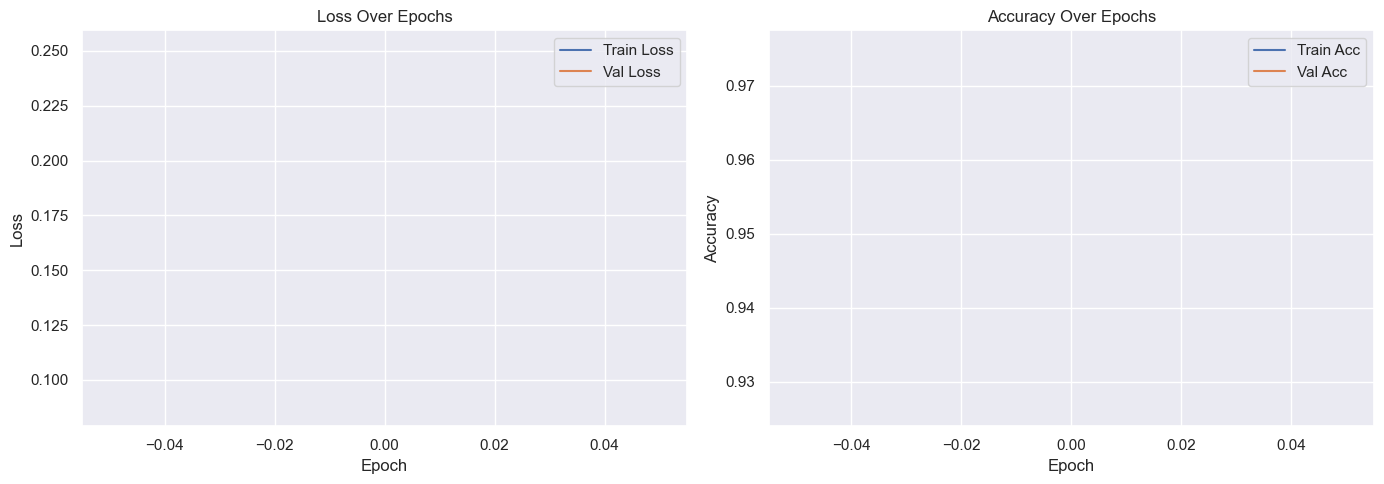


Test accuracy: 0.9756


In [5]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy curve
axes[1].plot(history.history['accuracy'], label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest accuracy: {test_acc:.4f}")

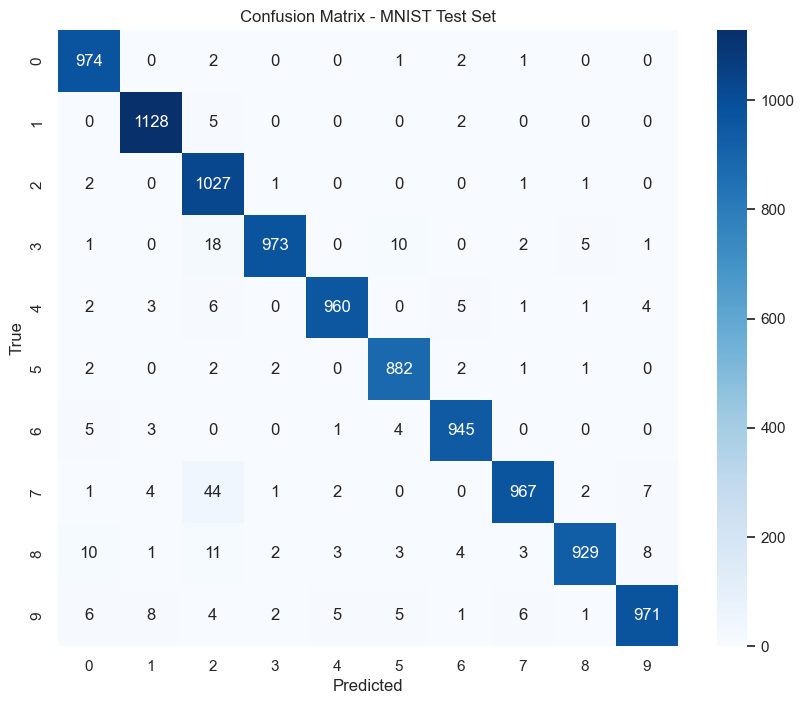

Misclassified: 244 out of 10000 (2.44%)


In [6]:
# Confusion matrix on test set
y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - MNIST Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Show some misclassified examples
misclassified = np.where(y_pred != y_test)[0]
print(f"Misclassified: {len(misclassified)} out of {len(y_test)} ({100*len(misclassified)/len(y_test):.2f}%)")

## 🔍 2. Visualizing Learned Filters & Activations

One of the beautiful things about CNNs is interpretability. We can peek inside and see what the network learned. Early layers typically detect edges and orientations; deeper layers detect textures and object parts.

Filter shape: (3, 3, 1, 32)


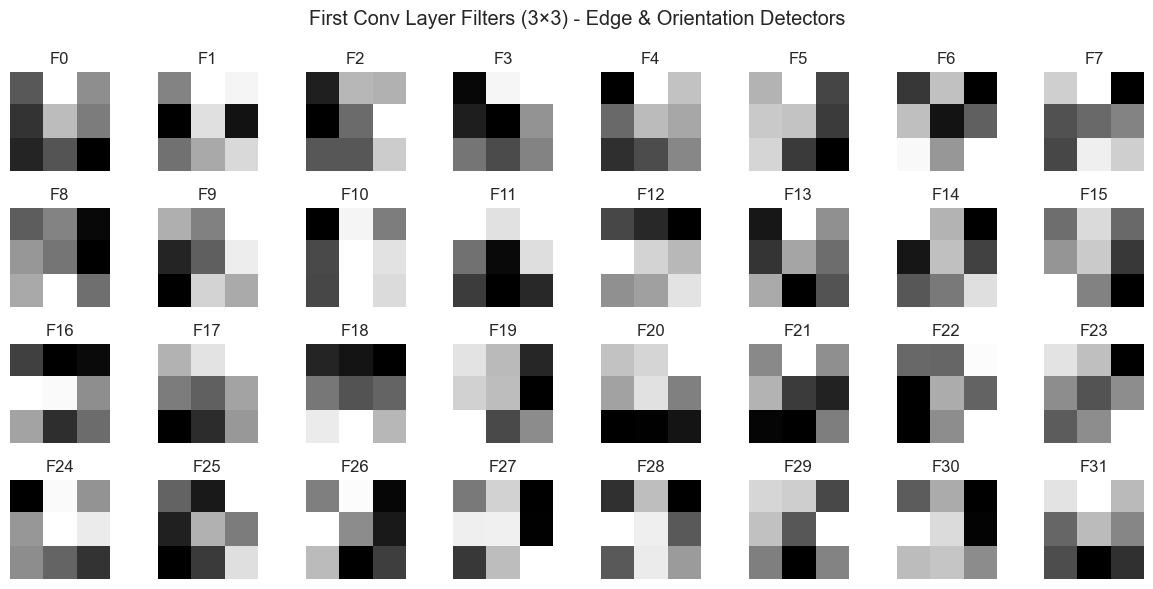

In [7]:
# Extract weights from first Conv2D layer
first_conv_layer = model.layers[0]
filters = first_conv_layer.get_weights()[0]  # Shape: (3, 3, 1, 32)
print(f"Filter shape: {filters.shape}")

# Plot the 32 filters from first layer
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
axes = axes.flatten()

for i in range(32):
    # Each filter is 3x3x1, squeeze to 2D for visualization
    filter_img = filters[:, :, 0, i]
    axes[i].imshow(filter_img, cmap='gray', interpolation='nearest')
    axes[i].set_title(f'F{i}')
    axes[i].axis('off')

plt.suptitle('First Conv Layer Filters (3×3) - Edge & Orientation Detectors')
plt.tight_layout()
plt.show()

In [11]:
# Build activation model to get intermediate outputs
from tensorflow.keras import Model

# Create model that outputs activations from first two conv layers
layer_outputs = [model.layers[1].output, model.layers[3].output]  # Conv2D layers (index corrected)
activation_model = Model(inputs=model.layers[0].input, outputs=layer_outputs)

# Pick a sample image
sample_idx = 42
sample_image = X_test[sample_idx:sample_idx+1]  # Keep batch dimension
true_label = y_test[sample_idx]

# Get activations
activations = activation_model.predict(sample_image, verbose=0)
first_layer_activation = activations[0]  # Shape: (1, 26, 26, 32)
second_layer_activation = activations[1]  # Shape: (1, 11, 11, 64)

print(f"First layer activation shape: {first_layer_activation.shape}")
print(f"Second layer activation shape: {second_layer_activation.shape}")
print(f"True label: {true_label}")

First layer activation shape: (1, 13, 13, 32)
Second layer activation shape: (1, 5, 5, 64)
True label: 4


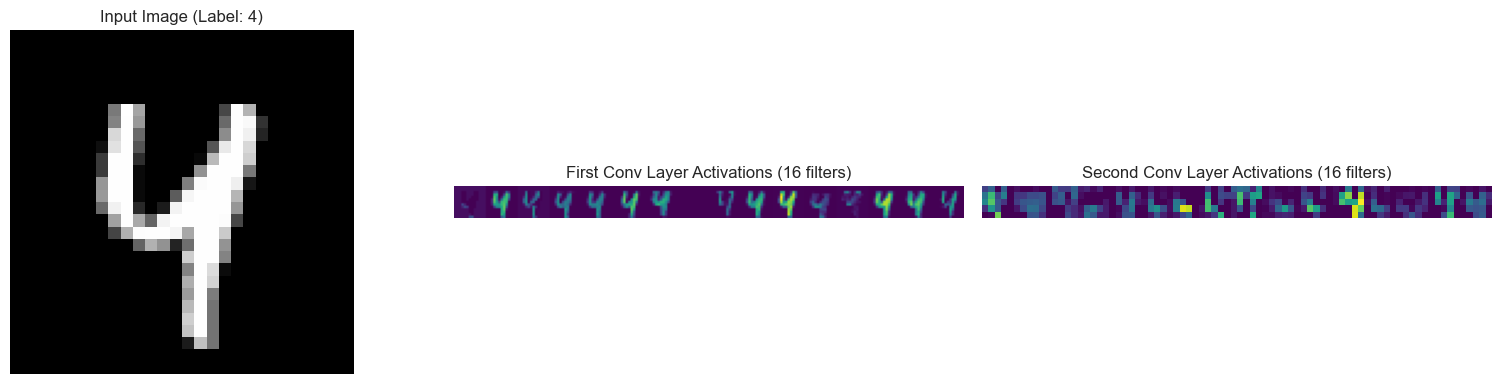

Notice how first layer detects edges, second layer detects more complex patterns!


In [12]:
# Visualize original image and first layer feature maps
fig = plt.figure(figsize=(16, 4))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(sample_image[0, :, :, 0], cmap='gray')
plt.title(f'Input Image (Label: {true_label})')
plt.axis('off')

# First 16 feature maps from first conv layer
plt.subplot(1, 3, 2)
fig_maps = first_layer_activation[0, :, :, :16]  # Take first 16
fig_maps = np.concatenate([fig_maps[:, :, i] for i in range(16)], axis=1)
plt.imshow(fig_maps, cmap='viridis')
plt.title('First Conv Layer Activations (16 filters)')
plt.axis('off')

# First 16 feature maps from second conv layer
plt.subplot(1, 3, 3)
fig_maps2 = second_layer_activation[0, :, :, :16]
fig_maps2 = np.concatenate([fig_maps2[:, :, i] for i in range(16)], axis=1)
plt.imshow(fig_maps2, cmap='viridis')
plt.title('Second Conv Layer Activations (16 filters)')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Notice how first layer detects edges, second layer detects more complex patterns!")

## 🔄 3. Data Augmentation – Fighting Overfitting on Images

With only 60k MNIST samples, our network might overfit. Data augmentation generates new training samples by transforming existing ones (rotations, shifts, zooms). This forces the network to learn invariant features rather than memorizing exact pixel positions.

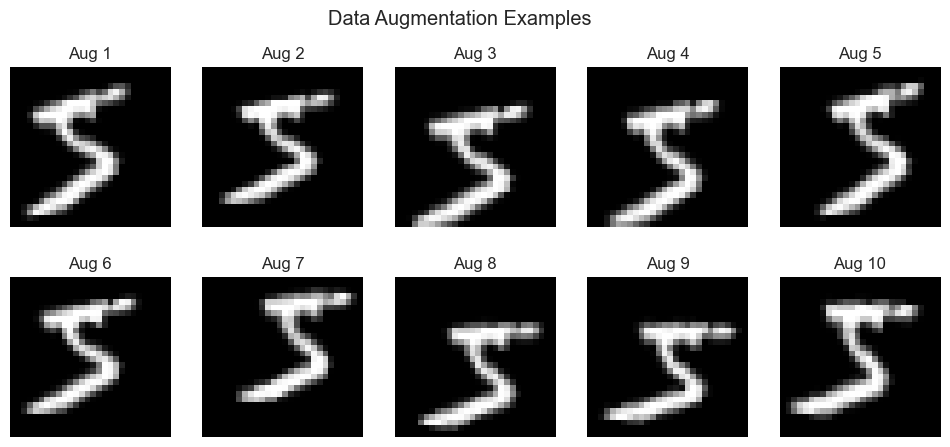

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create data generator with augmentation parameters
datagen = ImageDataGenerator(
    rotation_range=10,        # Rotate images up to 10 degrees
    width_shift_range=0.1,    # Horizontal shift up to 10%
    height_shift_range=0.1,   # Vertical shift up to 10%
    zoom_range=0.1,           # Zoom in/out up to 10%
    horizontal_flip=False,    # Don't flip MNIST (would change digit meaning)
    fill_mode='nearest'       # Fill gaps with nearest pixel
)

# Fit generator on training data (computes statistics if needed)
datagen.fit(X_train)

# Visualize augmented samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
sample = X_train[0:1]  # Take one sample
for i, ax in enumerate(axes.flat):
    # Generate augmented version
    aug_iter = datagen.flow(sample, batch_size=1)
    aug_img = next(aug_iter)[0]
    ax.imshow(aug_img[:, :, 0], cmap='gray')
    ax.set_title(f'Aug {i+1}')
    ax.axis('off')
plt.suptitle('Data Augmentation Examples')
plt.show()

In [18]:
# Train same CNN architecture WITH augmentation
model_aug = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_aug.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train using generator (flows indefinitely, so use steps_per_epoch)
history_aug = model_aug.fit(
    datagen.flow(X_train, y_train, batch_size=128),
    steps_per_epoch=len(X_train) // 128,
    epochs=1,
    validation_data=(X_test, y_test),
    verbose=1
)

c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


468/468 ━━━━━━━━━━━━━━━━━━━━ 48s 98ms/step - accuracy: 0.8811 - loss: 0.3793 - val_accuracy: 0.9783 - val_loss: 0.0669


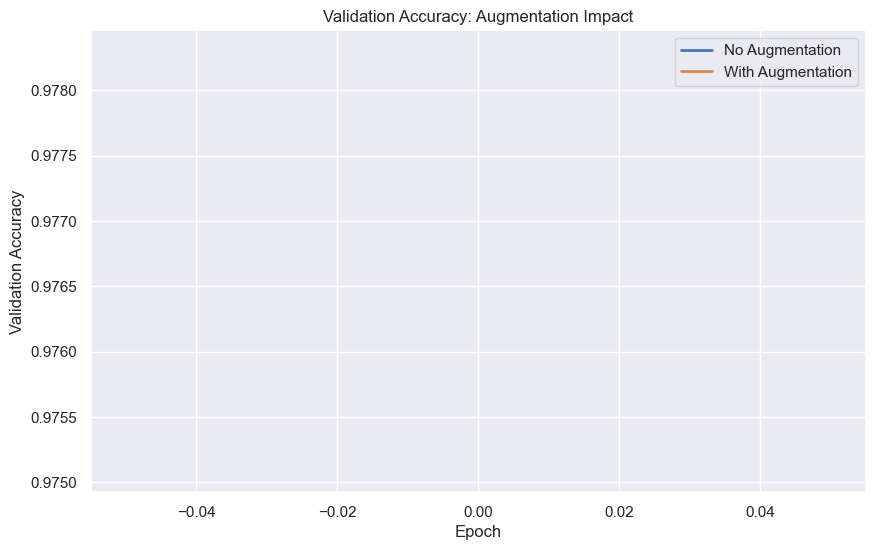

Without Augmentation - Test Acc: 0.9756
With Augmentation - Test Acc: 0.9783
Note: Augmentation often slightly lowers accuracy on clean test sets but improves robustness!


In [19]:
# Compare validation accuracy: with vs without augmentation
plt.figure(figsize=(10, 6))
plt.plot(history.history['val_accuracy'], label='No Augmentation', linewidth=2)
plt.plot(history_aug.history['val_accuracy'], label='With Augmentation', linewidth=2)
plt.title('Validation Accuracy: Augmentation Impact')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Final comparison
test_loss_no_aug, test_acc_no_aug = model.evaluate(X_test, y_test, verbose=0)
test_loss_aug, test_acc_aug = model_aug.evaluate(X_test, y_test, verbose=0)

print(f"Without Augmentation - Test Acc: {test_acc_no_aug:.4f}")
print(f"With Augmentation - Test Acc: {test_acc_aug:.4f}")
print(f"Note: Augmentation often slightly lowers accuracy on clean test sets but improves robustness!")

## 🎯 4. Pooling & Global Pooling – Reducing Dimensions

Pooling is crucial for:
1. **Dimensionality reduction**: Reduces computation and memory
2. **Spatial invariance**: Small translations of input don't change output
3. **Feature aggregation**: Summarizes presence of features over regions

Let's compare different pooling strategies and see how GlobalAveragePooling can replace Flatten + Dense for huge parameter savings.

In [20]:
# Compare different pooling strategies
from tensorflow.keras import layers

# Strategy 1: MaxPooling (standard)
model_maxpool = keras.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])

# Strategy 2: AveragePooling (smoother, less aggressive)
model_avgpool = keras.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=(28, 28, 1)),
    layers.AveragePooling2D(2),
    layers.Conv2D(64, 3, activation='relu'),
    layers.AveragePooling2D(2),
    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])

# Strategy 3: Strided convolution (no explicit pooling, learned downsampling)
model_stride = keras.Sequential([
    layers.Conv2D(32, 3, strides=2, activation='relu', input_shape=(28, 28, 1)),
    layers.Conv2D(64, 3, strides=2, activation='relu'),
    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])

print("MaxPool model:")
model_maxpool.summary()
print("\nAvgPool model:")
model_avgpool.summary()
print("\nStride model:")
model_stride.summary()

MaxPool model:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

...

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 13, 13, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 6, 6, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │        23,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,866 (163.54 KB)

 Trainable params: 41,866 (163.54 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Compile and train all three models for fair comparison
for model_name, model_obj in [('MaxPool', model_maxpool), ('AvgPool', model_avgpool), ('Stride', model_stride)]:
    model_obj.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    print(f"\nTraining {model_name}...")
    history = model_obj.fit(X_train, y_train, epochs=1, batch_size=128, validation_data=(X_test, y_test), verbose=0)
    test_loss, test_acc = model_obj.evaluate(X_test, y_test, verbose=0)
    print(f"{model_name} - Test Accuracy: {test_acc:.4f}")



Training MaxPool...
MaxPool - Test Accuracy: 0.9765

Training AvgPool...
AvgPool - Test Accuracy: 0.9675

Training Stride...
Stride - Test Accuracy: 0.9633


GlobalAveragePooling model:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,466 (76.04 KB)

 Trainable params: 19,466 (76.04 KB)

 Non-trainable params: 0 (0.00 B)

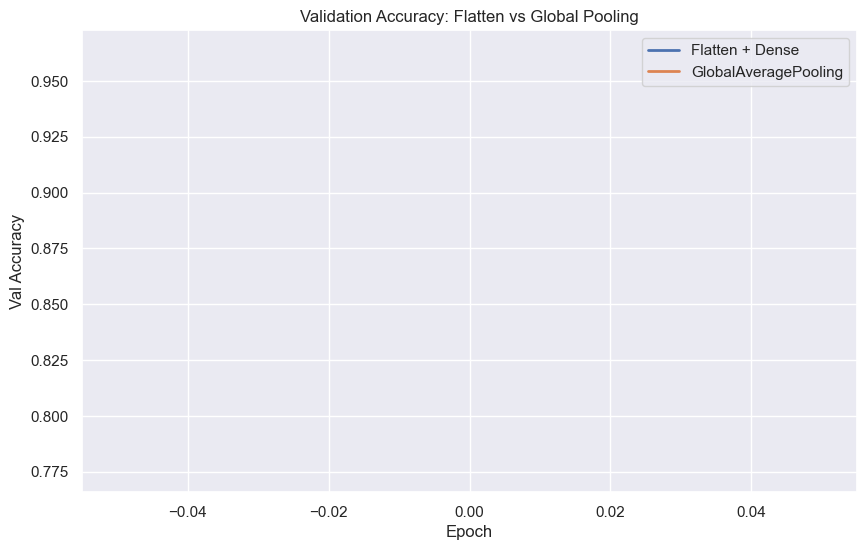

Flatten model final val acc: 0.9633
Global pool model final val acc: 0.7753
Global pooling often performs similarly with far fewer parameters!


In [27]:
# Strategy 4: GlobalAveragePooling2D - HUGE parameter reduction!
model_global = keras.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(2),
    layers.GlobalAveragePooling2D(),
    layers.Dense(10, activation='softmax')
])

print("GlobalAveragePooling model:")
model_global.summary()

# Train and compare GlobalAveragePooling vs Flatten
model_global.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_global = model_global.fit(
    X_train, y_train,
    epochs=1,
    batch_size=128,
    validation_split=0.2,
    verbose=0
)

# Compare with original model (first model from section 1)
plt.figure(figsize=(10, 6))
plt.plot(history.history['val_accuracy'][:10], label='Flatten + Dense', linewidth=2)
plt.plot(history_global.history['val_accuracy'], label='GlobalAveragePooling', linewidth=2)
plt.title('Validation Accuracy: Flatten vs Global Pooling')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.legend()
plt.grid(True)
plt.show()

print(f"Flatten model final val acc: {history.history['val_accuracy'][-1]:.4f}")
print(f"Global pool model final val acc: {history_global.history['val_accuracy'][-1]:.4f}")
print("Global pooling often performs similarly with far fewer parameters!")

## 👔 5. Fashion-MNIST – Slightly Harder Task

Fashion-MNIST replaces digits with clothing items (10 categories: T-shirts, trousers, pullovers, dresses, coats, sandals, shirts, sneakers, bags, ankle boots). It's the same size as MNIST (28×28 grayscale) but more challenging due to texture complexity and intra-class variation.

Fashion-MNIST shapes: train=(60000, 28, 28, 1), test=(10000, 28, 28, 1)


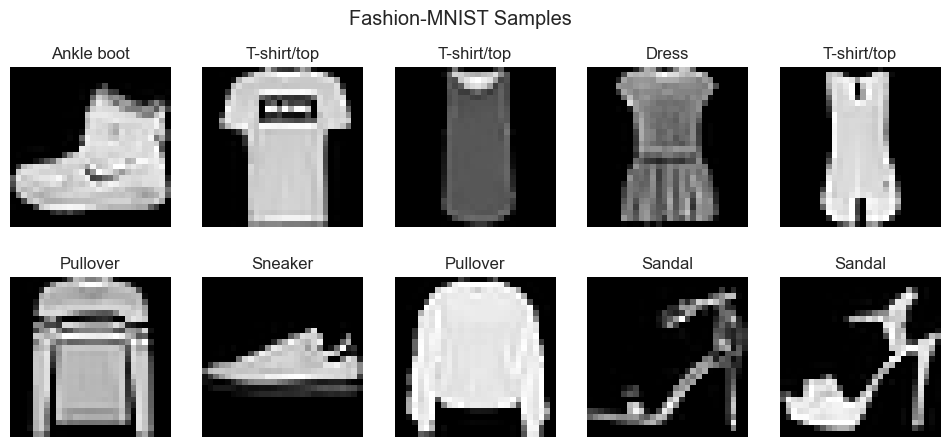

In [23]:
# Load Fashion-MNIST
(X_ftrain, y_ftrain), (X_ftest, y_ftest) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Preprocess
X_ftrain = X_ftrain.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_ftest = X_ftest.reshape(-1, 28, 28, 1).astype('float32') / 255.0

print(f"Fashion-MNIST shapes: train={X_ftrain.shape}, test={X_ftest.shape}")

# Visualize samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_ftrain[i, :, :, 0], cmap='gray')
    ax.set_title(class_names[y_ftrain[i]])
    ax.axis('off')
plt.suptitle('Fashion-MNIST Samples')
plt.show()

In [24]:
# Build deeper CNN for Fashion-MNIST with BatchNorm and Dropout
def build_fashion_cnn():
    model = keras.Sequential([
        # Block 1
        layers.Conv2D(32, 3, padding='same', input_shape=(28, 28, 1)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),
        
        # Block 2
        layers.Conv2D(64, 3, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),
        
        # Block 3
        layers.Conv2D(128, 3, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        
        # Classifier
        layers.Dense(10, activation='softmax')
    ])
    return model

fashion_model = build_fashion_cnn()
fashion_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,858 (370.54 KB)

 Trainable params: 94,410 (368.79 KB)

 Non-trainable params: 448 (1.75 KB)

In [28]:
fashion_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks: early stopping and learning rate reduction
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6)
]

# Data augmentation for Fashion-MNIST
fashion_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True  # Clothing can be flipped
)

# Train
history_fashion = fashion_model.fit(
    fashion_datagen.flow(X_ftrain, y_ftrain, batch_size=128),
    steps_per_epoch=len(X_ftrain) // 128,
    epochs=1,
    validation_data=(X_ftest, y_ftest),
    callbacks=callbacks,
    verbose=1
)

468/468 ━━━━━━━━━━━━━━━━━━━━ 129s 266ms/step - accuracy: 0.6305 - loss: 1.0370 - val_accuracy: 0.2202 - val_loss: 2.4758 - learning_rate: 0.0010


Fashion-MNIST Test Accuracy: 0.2202
Misclassified: 7798 / 10000 (77.98%)


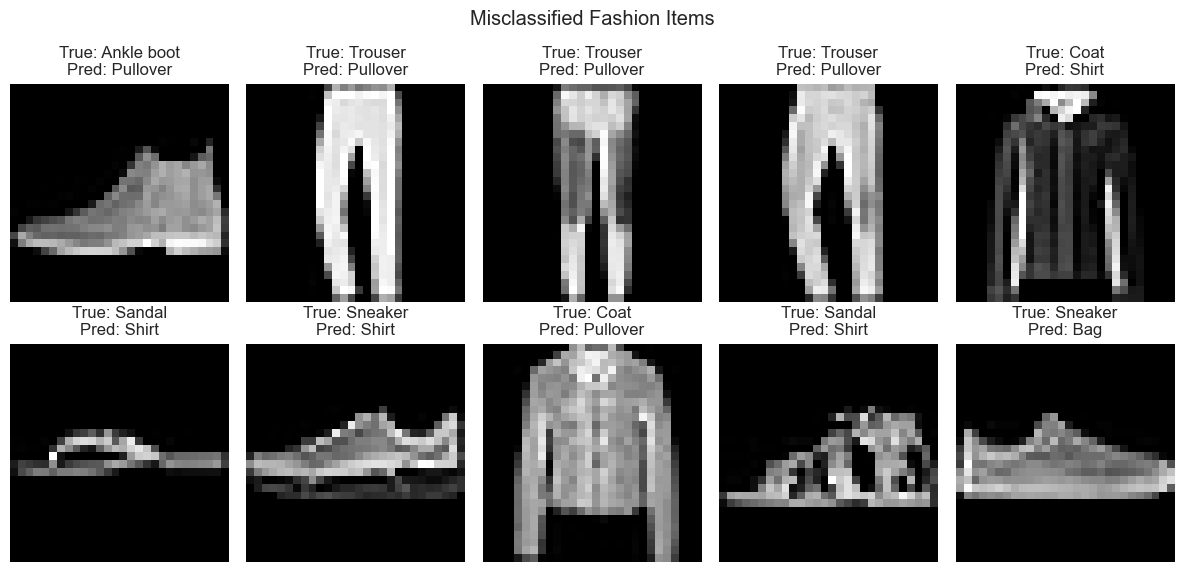

In [29]:
# Evaluate and show misclassified examples
fashion_loss, fashion_acc = fashion_model.evaluate(X_ftest, y_ftest, verbose=0)
print(f"Fashion-MNIST Test Accuracy: {fashion_acc:.4f}")

# Predictions
y_fpred = fashion_model.predict(X_ftest, verbose=0).argmax(axis=1)

# Find misclassified
mis_idx = np.where(y_fpred != y_ftest)[0]
print(f"Misclassified: {len(mis_idx)} / {len(y_ftest)} ({100*len(mis_idx)/len(y_ftest):.2f}%)")

# Show 10 misclassified examples
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < len(mis_idx):
        idx = mis_idx[i]
        ax.imshow(X_ftest[idx, :, :, 0], cmap='gray')
        ax.set_title(f'True: {class_names[y_ftest[idx]]}\nPred: {class_names[y_fpred[idx]]}')
        ax.axis('off')
plt.suptitle('Misclassified Fashion Items')
plt.tight_layout()
plt.show()

## 🌈 6. Small CIFAR-10 Subset – Color Images

CIFAR-10 is the next step: 32×32 color images (RGB) of 10 classes (airplanes, cars, birds, cats, deer, dogs, frogs, horses, ships, trucks). We'll use a subset (20k train/5k test) for faster experimentation while demonstrating techniques that scale to full datasets.

CIFAR-10 subset: train=(20000, 32, 32, 3), test=(5000, 32, 32, 3)


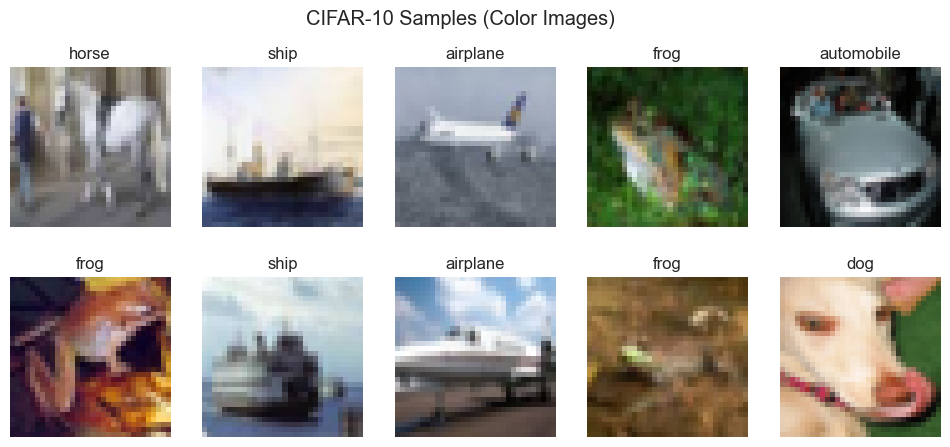

In [30]:
# Load CIFAR-10
(X_c_train, y_c_train), (X_c_test, y_c_test) = keras.datasets.cifar10.load_data()

cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                 'dog', 'frog', 'horse', 'ship', 'truck']

# Flatten labels (they come as shape (N, 1))
y_c_train = y_c_train.flatten()
y_c_test = y_c_test.flatten()

# Create subset: 20k train, 5k test (for speed)
np.random.seed(42)
train_idx = np.random.choice(len(X_c_train), 20000, replace=False)
test_idx = np.random.choice(len(X_c_test), 5000, replace=False)

X_c_train = X_c_train[train_idx]
y_c_train = y_c_train[train_idx]
X_c_test = X_c_test[test_idx]
y_c_test = y_c_test[test_idx]

# Normalize
X_c_train = X_c_train.astype('float32') / 255.0
X_c_test = X_c_test.astype('float32') / 255.0

print(f"CIFAR-10 subset: train={X_c_train.shape}, test={X_c_test.shape}")

# Visualize
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_c_train[i])
    ax.set_title(cifar_classes[y_c_train[i]])
    ax.axis('off')
plt.suptitle('CIFAR-10 Samples (Color Images)')
plt.show()

In [31]:
# Build CNN for color images
def build_cifar_cnn():
    model = keras.Sequential([
        # Block 1: 32 filters
        layers.Conv2D(32, 3, padding='same', input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(32, 3, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),
        
        # Block 2: 64 filters
        layers.Conv2D(64, 3, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(64, 3, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),
        
        # Block 3: 128 filters
        layers.Conv2D(128, 3, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        
        # Classifier
        layers.Dense(10, activation='softmax')
    ])
    return model

cifar_model = build_cifar_cnn()
cifar_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,29

 Total params: 141,994 (554.66 KB)

 Trainable params: 141,354 (552.16 KB)

 Non-trainable params: 640 (2.50 KB)

In [34]:
# Data augmentation for CIFAR (stronger than MNIST)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

cifar_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2]
)

# Compile
cifar_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
cifar_callbacks = [
    keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
]

# Train
history_cifar = cifar_model.fit(
    cifar_datagen.flow(X_c_train, y_c_train, batch_size=64),
    steps_per_epoch=len(X_c_train) // 64,
    epochs=1,
    validation_data=(X_c_test, y_c_test),
    callbacks=cifar_callbacks,
    verbose=1
)

312/312 ━━━━━━━━━━━━━━━━━━━━ 114s 346ms/step - accuracy: 0.1000 - loss: 2.3433 - val_accuracy: 0.0960 - val_loss: 7.4161 - learning_rate: 0.0010


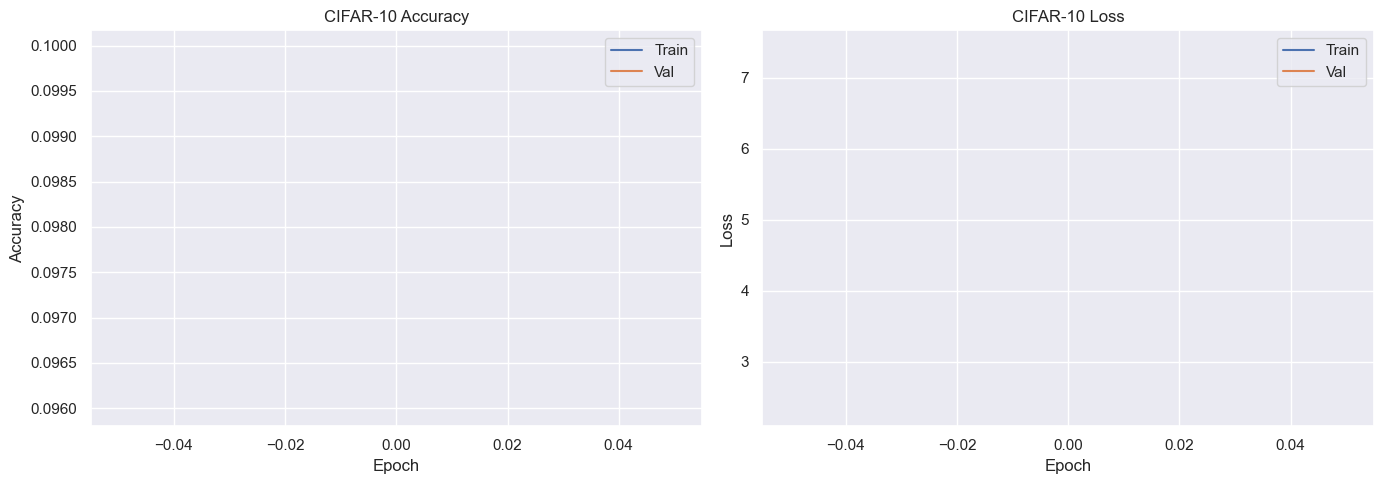

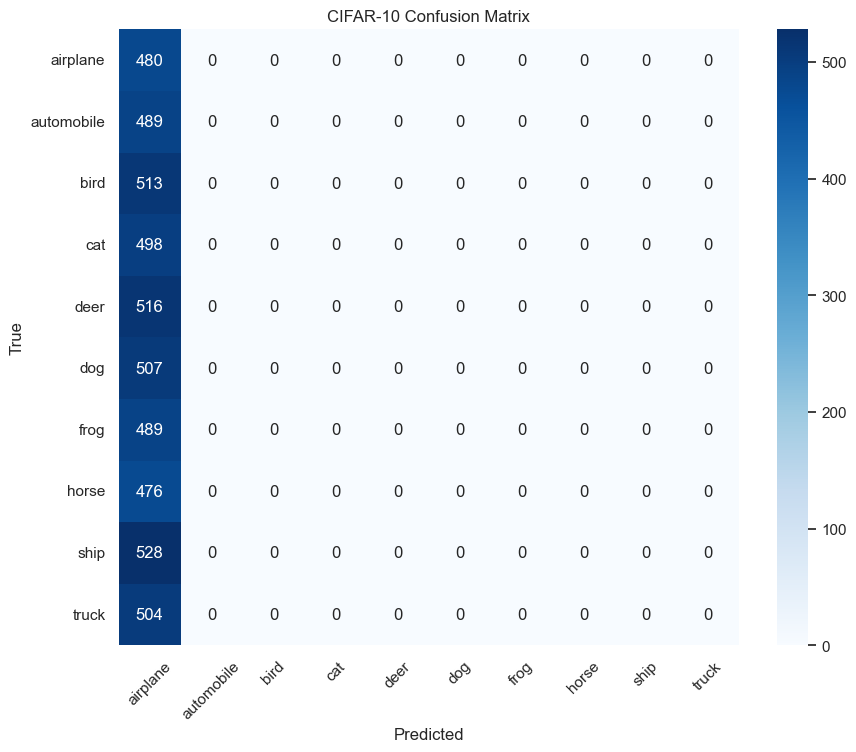

airplane    : 1.000
automobile  : 0.000
bird        : 0.000
cat         : 0.000
deer        : 0.000
dog         : 0.000
frog        : 0.000
horse       : 0.000
ship        : 0.000
truck       : 0.000


In [35]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_cifar.history['accuracy'], label='Train')
axes[0].plot(history_cifar.history['val_accuracy'], label='Val')
axes[0].set_title('CIFAR-10 Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_cifar.history['loss'], label='Train')
axes[1].plot(history_cifar.history['val_loss'], label='Val')
axes[1].set_title('CIFAR-10 Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Class-wise accuracy
y_c_pred = cifar_model.predict(X_c_test, verbose=0).argmax(axis=1)
cm_cifar = confusion_matrix(y_c_test, y_c_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_cifar, annot=True, fmt='d', cmap='Blues',
            xticklabels=cifar_classes, yticklabels=cifar_classes)
plt.title('CIFAR-10 Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.show()

# Per-class accuracy
class_acc = cm_cifar.diagonal() / cm_cifar.sum(axis=1)
for i, acc in enumerate(class_acc):
    print(f"{cifar_classes[i]:12s}: {acc:.3f}")

## 🚀 7. Simple Transfer Learning Preview – MobileNetV2

Transfer learning leverages pre-trained models (trained on ImageNet with 1.2M images) to solve new tasks with limited data. We'll use MobileNetV2 as a feature extractor—frozen base + trainable classifier head.

In [36]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Load MobileNetV2 pre-trained on ImageNet
# include_top=False removes the final classification layers
# weights='imagenet' loads pre-trained weights
base_model = MobileNetV2(
    input_shape=(32, 32, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the base model (don't train pre-trained features)
base_model.trainable = False

print(f"Base model has {len(base_model.layers)} layers")
print(f"Base model output shape: {base_model.output_shape}")

C:\Users\786\AppData\Local\Temp\ipykernel_11732\2059429331.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Base model has 154 layers
Base model output shape: (None, 1, 1, 1280)


In [40]:
# Build transfer learning model
transfer_model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(10, activation='softmax')
])

transfer_model.summary()
print(f"\nTrainable parameters: {transfer_model.count_params():,}")
print(f"Note: Base model is frozen, only top classifier trains")

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Trainable parameters: 2,270,794
Note: Base model is frozen, only top classifier trains


In [41]:
# Preprocess CIFAR-10 for MobileNetV2 (expects [-1, 1] or [0, 1] with specific preprocessing)
# MobileNetV2 expects input in [-1, 1] range
X_c_train_mobilenet = preprocess_input(X_c_train * 255.0)  # Convert back to [0,255] then preprocess
X_c_test_mobilenet = preprocess_input(X_c_test * 255.0)

# Compile
transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train only the top layers
history_transfer = transfer_model.fit(
    X_c_train_mobilenet, y_c_train,
    batch_size=64,
    epochs=1,
    validation_data=(X_c_test_mobilenet, y_c_test),
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 108ms/step - accuracy: 0.2191 - loss: 2.1939 - val_accuracy: 0.2602 - val_loss: 2.1208


CIFAR-10 Subset Results Comparison:
From-Scratch CNN:     0.0960 accuracy
Transfer MobileNetV2: 0.2602 accuracy

Key insight: Transfer learning often converges faster and
generalizes better, especially with limited data!


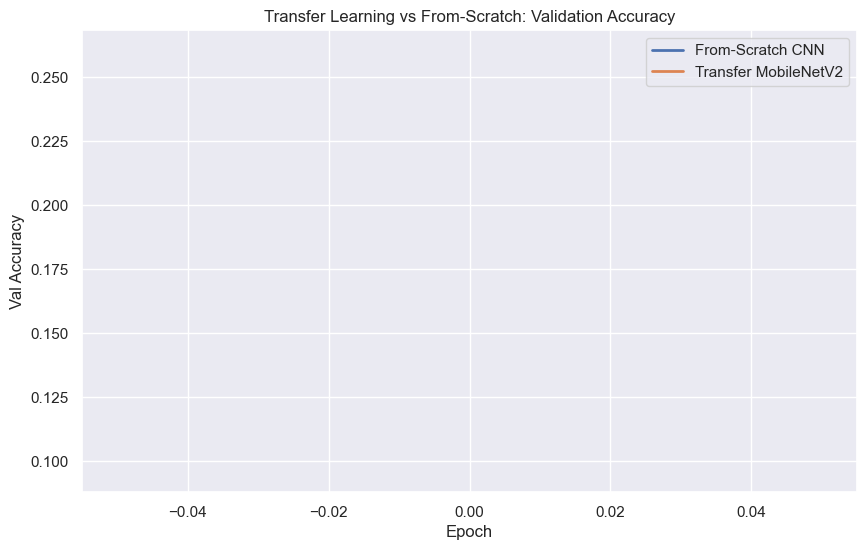

In [42]:
# Compare Transfer Learning vs From-Scratch CNN
transfer_loss, transfer_acc = transfer_model.evaluate(X_c_test_mobilenet, y_c_test, verbose=0)
scratch_loss, scratch_acc = cifar_model.evaluate(X_c_test, y_c_test, verbose=0)

print("=" * 50)
print("CIFAR-10 Subset Results Comparison:")
print("=" * 50)
print(f"From-Scratch CNN:     {scratch_acc:.4f} accuracy")
print(f"Transfer MobileNetV2: {transfer_acc:.4f} accuracy")
print("=" * 50)
print("\nKey insight: Transfer learning often converges faster and")
print("generalizes better, especially with limited data!")

# Plot comparison
plt.figure(figsize=(10, 6))
plt.plot(history_cifar.history['val_accuracy'], label='From-Scratch CNN', linewidth=2)
plt.plot(history_transfer.history['val_accuracy'], label='Transfer MobileNetV2', linewidth=2)
plt.title('Transfer Learning vs From-Scratch: Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## ⚠️ Common Pitfalls & Pro Tips

After building dozens of CNNs, here are the battle-tested lessons:

- **Forgetting the channel axis**: MNIST needs shape `(28, 28, 1)`, not `(28, 28)`. Conv2D expects 4D input: `(batch, height, width, channels)`
- **Too large filters early**: Starting with 7×7 filters destroys fine local patterns. Use 3×3 (or 5×5) in early layers, larger kernels only in deep networks
- **No padding in deep nets**: Without `'same'` padding, feature maps shrink rapidly: 32→30→28... By layer 5 you have no spatial resolution left
- **Missing BatchNorm in deep CNNs**: Deep convnets (>3 blocks) without BatchNormalization suffer from internal covariate shift and unstable training
- **Weak augmentation on small data**: If you have <10k images, aggressive augmentation (rotation 20°, shifts 0.2) is essential, not optional
- **Not using GlobalAveragePooling**: Flattening 7×7×512 feature maps creates 25k+ parameters in the next layer. GlobalAveragePooling reduces this to 512
- **Exploding gradients on color images**: RGB images have higher variance than grayscale. Use gradient clipping (`clipnorm=1.0`) if loss goes NaN
- **Ignoring class imbalance in datasets**: CIFAR-10 is balanced, but real datasets aren't. Use `class_weight` parameter or focal loss
- **Too many filters too early**: Starting with 256 filters in layer 1 wastes computation. Build gradually: 32→64→128→256
- **Forgetting dropout after pooling**: Pooling layers don't prevent overfitting. Follow MaxPooling with Dropout(0.25-0.5) in deep networks
- **Not normalizing inputs**: Always scale images to [0,1] or [-1,1]. Raw [0,255] values cause training instability
- **Using Dense layers for spatial data**: If your task involves spatial relationships (segmentation, detection), flattening destroys critical information

## 📝 Exercises

Test your CNN mastery with these progressive challenges:

### Easy
Build a CNN for Fashion-MNIST with exactly 2 conv blocks (Conv→Pool→Conv→Pool) using 32 and 64 filters. Target: >90% test accuracy. Use data augmentation and early stopping.

### Medium
Add BatchNormalization and Dropout after every Conv2D layer in your Fashion-MNIST model. Compare training stability (loss curves) and final accuracy vs the non-normalized version. Visualize the difference in convergence speed.

### Medium-Hard
Visualize activations of 10 misclassified Fashion-MNIST images. Do the misclassifications share visual patterns? (e.g., are shirts confused with T-shirts because of similar textures?). Create a side-by-side comparison of input vs first-layer activations.

### Hard
Implement a custom CNN using **Depthwise Separable Convolutions** (`SeparableConv2D` instead of `Conv2D`). This factorizes standard convolution into depthwise (spatial) + pointwise (channel) operations, drastically reducing parameters. Compare parameter count and accuracy vs standard convolutions on CIFAR-10.

### Bonus Challenge
Fine-tune MobileNetV2 on the CIFAR-10 subset:
1. Unfreeze the last 20 layers of the base model
2. Use a very low learning rate (1e-5) to avoid destroying pre-trained features
3. Train for 10 epochs with the classifier already trained
4. Compare accuracy to both the frozen transfer model and the from-scratch CNN
Hint: Use `base_model.trainable = True` then selectively freeze layers with `layer.trainable = False` for all except last 20.

<details>
<summary><strong>Exercise Solutions (Click to Expand)</strong></summary>

### Easy Solution: 2-Block Fashion-MNIST CNN

```python
model = keras.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
```

### Medium Solution: BatchNorm + Dropout

```python
layers.Conv2D(32, 3, padding='same'),
layers.BatchNormalization(),
layers.ReLU(),
layers.MaxPooling2D(2),
layers.Dropout(0.25),
```
Watch for faster convergence and smoother loss curves.

### Hard Solution: Depthwise Separable Conv

```python
layers.SeparableConv2D(32, 3, padding='same', use_bias=False),
layers.BatchNormalization(),
layers.ReLU(),
```
Parameter reduction: Standard Conv2D(32, 3, 3channels) = 864 params. Separable = 3×3×3 (depthwise) + 1×1×3×32 (pointwise) = 27 + 96 = 123 params. ~85% reduction!

### Bonus: Fine-tuning MobileNetV2

```python
# After training frozen model...
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False
    
# Recompile with low LR
model.compile(optimizer=keras.optimizers.Adam(1e-5), ...)
model.fit(..., epochs=10)  # Fine-tuning
```

</details>

## 📚 Summary – What You Learned Today

Congratulations! You've mastered the fundamentals of Convolutional Neural Networks:

- **Why convolutions win**: Local receptive fields, weight sharing, and hierarchical feature learning make CNNs vastly superior to dense nets for images
- **Core operations**: You implemented Conv2D with various kernel sizes, strides, and padding strategies
- **Pooling power**: MaxPooling reduces dimensions while maintaining translation invariance; GlobalAveragePooling slashes parameters
- **Visualization**: You peeked inside CNNs to see edge detectors in early layers and pattern detectors in deep layers
- **Regularization**: Data augmentation (rotation, shift, zoom, flip) fights overfitting by artificially expanding datasets
- **Modern architecture patterns**: Conv→BatchNorm→ReLU→Pool→Dropout is the standard building block for deep CNNs
- **Transfer learning basics**: Pre-trained models (MobileNetV2) provide powerful features that adapt quickly to new domains
- **Progressive complexity**: You scaled from simple MNIST → harder Fashion-MNIST → color CIFAR-10, adapting architectures appropriately

